# Расчет параметров эффективности математической модели

In [92]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma as gamma_dist

from exceptions import MathModelException
from config import MathModelInput, load_config
import executor
import replicaset
import user

from render_typst import FormulaRenderer, get_typst_context

TYPST_PATH: Path = Path("../diploma/math-stuff.typ")
TYPST_RENDERER: FormulaRenderer = FormulaRenderer()
TYPST_CONTEXT: str = get_typst_context(TYPST_PATH)


def output(t: str):
    TYPST_RENDERER.render(TYPST_CONTEXT + t)

Здесь задается конфиг, по которому будут рассчитаны параметры эффективности

In [93]:
CONFIG_PATH = "configs/example.yaml"

In [94]:
MATH_MODEL_INPUT: MathModelInput = load_config(CONFIG_PATH)

print(f"Загруженные настройки: {MATH_MODEL_INPUT}")

Загруженные настройки: intensity_search_LSI=496770.0 intensity_update_LSI=10000.0 intensity_search_GSI=10000.0 intensity_update_GSI=10000.0 replicaset_count=1 cluster_time_k=1.5 cluster_time_theta=0.02 cluster_net_speed=100000000.0 user_time_k=2.0 user_time_theta=0.2 user_net_speed=1000000.0 row_size=128 data_cardinality=1000 fk_cardinality=100 cpu_frequency=4000000000.0 mem_frequency=10000000.0 wal_time=0.002 timeout=2.0 btree_order=4096


Добавим алиасы для удоства

In [95]:
replicaset_count = MATH_MODEL_INPUT.replicaset_count

cluster_time_theta, cluster_time_k = (
    MATH_MODEL_INPUT.cluster_time_theta,
    MATH_MODEL_INPUT.cluster_time_k,
)
user_time_theta, user_time_k = (
    MATH_MODEL_INPUT.user_time_theta,
    MATH_MODEL_INPUT.user_time_k,
)

## Алгоритмы для ЛВИ

### Поиск в ЛВИ

Вычислим время работы исполнителя

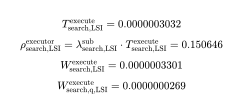

In [96]:
data_cardinality_per_replicaset = replicaset.data_cardinality_per_replicaset(
    MATH_MODEL_INPUT.data_cardinality, MATH_MODEL_INPUT.replicaset_count
)
pk_per_fk_cardinality_per_replicaset = replicaset.pk_per_fk_cardinality_per_replicaset(
    data_cardinality_per_replicaset, MATH_MODEL_INPUT.fk_cardinality
)

time_execute_search_LSI = executor.time_execute_search_LSI(
    data_cardinality_per_replicaset,
    MATH_MODEL_INPUT.btree_order,
    pk_per_fk_cardinality_per_replicaset,
    MATH_MODEL_INPUT.cpu_frequency,
    MATH_MODEL_INPUT.mem_frequency,
)

subintensity_search_LSI = MATH_MODEL_INPUT.intensity_search_LSI
load_executor_search_LSI = executor.load(
    subintensity_search_LSI, time_execute_search_LSI
)

if load_executor_search_LSI > 1:
    raise MathModelException(
        f"Исполнитель не справляется с нагрузкой! загрузка системы равна {load_executor_search_LSI:.3f}"
    )

queue_length_execute_search_LSI = (
    executor.pollaczek_khinchin_deterministic_queue_length(
        subintensity_search_LSI, time_execute_search_LSI
    )
)
service_time_execute_search_LSI = executor.littles_law_deterministic(
    queue_length_execute_search_LSI, subintensity_search_LSI
)
queue_time_execute_search_LSI = executor.queue_time_deterministic(
    service_time_execute_search_LSI, time_execute_search_LSI
)

res = rf"""
$#time_execute_search_LSI = "{time_execute_search_LSI:.10f}"$

$#load_executor_search_LSI = #subintensity_search_LSI dot #time_execute_search_LSI = {load_executor_search_LSI:5f}$

$#service_time_execute_search_LSI = {service_time_execute_search_LSI:.10f}$

$#queue_time_execute_search_LSI = {queue_time_execute_search_LSI:.10f}$
"""
output(res)

Рассчитаем время работы координатора и общее время ожидания пользователя

Интеграл плотности СВ = 0.999917
M[Z]: 0.461584
D[Z]: 0.082400


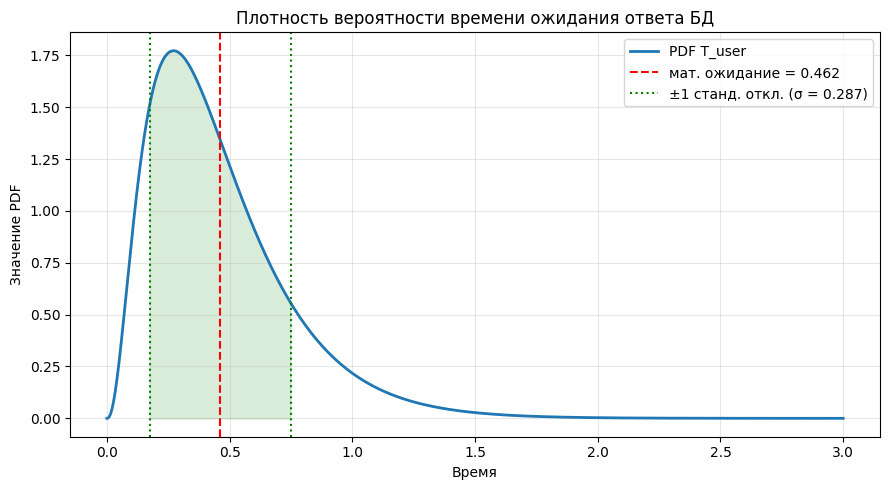

In [ ]:
exec_plan_size = replicaset.exec_plan_size(MATH_MODEL_INPUT.row_size)
query_size = replicaset.query_size(MATH_MODEL_INPUT.row_size)

# детерминированная часть задержки работы исполнителя
deterministic_part_of_tcsi_search_LSI = (
    exec_plan_size + MATH_MODEL_INPUT.row_size * pk_per_fk_cardinality_per_replicaset
) / MATH_MODEL_INPUT.cluster_net_speed

# детерминированная часть задержки
deterministic_part_of_tus = (
    query_size
    + MATH_MODEL_INPUT.row_size
    * pk_per_fk_cardinality_per_replicaset
    * MATH_MODEL_INPUT.replicaset_count
) / MATH_MODEL_INPUT.user_net_speed + deterministic_part_of_tcsi_search_LSI


# сетка для расчета случайных величин
dx = 0.0002
x_grid = np.arange(0.0, 30.0 + dx, dx)

# задержка пользователь-координатор запрос-ответ
time_user_request_response_pdf = gamma_dist.pdf(
    x_grid, a=user_time_k, scale=user_time_theta
)

# задержка координатор-исполнитель запрос-ответ
time_cluster_request_response_i_pdf = gamma_dist.pdf(
    x_grid,
    a=cluster_time_k,
    scale=cluster_time_theta * 2,
)
time_cluster_request_response_i_cdf = gamma_dist.cdf(
    x_grid,
    a=cluster_time_k,
    scale=cluster_time_theta * 2,
)
# макс. задержка координатор-исполнитель запрос-ответ
time_cluster_request_response_max_pdf = (
    MATH_MODEL_INPUT.replicaset_count
    * time_cluster_request_response_i_cdf ** (MATH_MODEL_INPUT.replicaset_count - 1)
    * time_cluster_request_response_i_pdf
)

# светрка задержки пользователь-координатор и координатор-исполнитель запрос-ответ
time_request_response_pdf = (
    np.convolve(time_user_request_response_pdf, time_cluster_request_response_max_pdf)
    * dx
)
# сдвинутая сетка, т.к. добавляем константу
time_request_response_grid = np.arange(0.0, 2 * x_grid[-1] + dx, dx)[
    : len(time_request_response_pdf)
]
time_request_response_grid_offset = (
    time_request_response_grid + deterministic_part_of_tus
)

# проверим, что интеграл плотности равен единице
time_request_response_pdf_integral = np.trapezoid(
    time_request_response_pdf, time_request_response_grid_offset
)
print(f"Интеграл плотности СВ = {time_request_response_pdf_integral:.6f}")

# мат. ожидание и дисперсия общения пользователь-координатор
time_user_request_response_mean, time_user_request_response_variance = (
    user_time_k * user_time_theta,
    user_time_k * user_time_theta**2,
)
# мат. ожидание и дисперсия общения максимума координатор-исполнитель
time_cluster_request_response_max_mean: float = np.trapezoid(
    x_grid * time_cluster_request_response_max_pdf, x_grid
)  # type: ignore
time_cluster_request_response_max_moment_2: float = np.trapezoid(
    x_grid**2 * time_cluster_request_response_max_pdf, x_grid
)  # type: ignore
time_cluster_request_response_max_variance = (
    time_cluster_request_response_max_moment_2
    - time_cluster_request_response_max_mean**2
)
# общие мат. ожидание и дисперсия
time_user_search_LSI_mean = (
    time_user_request_response_mean
    + time_cluster_request_response_max_mean
    + deterministic_part_of_tus
)
time_user_search_LSI_variance = (
    time_user_request_response_variance + time_cluster_request_response_max_variance
)

print(f"M[Z]: {time_user_search_LSI_mean:.6f}")
print(f"D[Z]: {time_user_search_LSI_variance:.6f}")

plt.figure(figsize=(9, 5))
time_user_search_LSI_plot_interval = (time_request_response_grid >= 0) & (
    time_request_response_grid <= 3
)
plt.plot(
    time_request_response_grid[time_user_search_LSI_plot_interval],
    time_request_response_pdf[time_user_search_LSI_plot_interval],
    label="PDF T_user",
    lw=2,
)
plt.axvline(
    time_user_search_LSI_mean,
    color="r",
    ls="--",
    label=f"мат. ожидание = {time_user_search_LSI_mean:.3f}",
)
time_user_search_LSI_std_deviance = np.sqrt(time_user_search_LSI_variance)
plt.axvline(
    time_user_search_LSI_mean - time_user_search_LSI_std_deviance,
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"±1 станд. откл. (σ = {time_user_search_LSI_std_deviance:.3f})",
)
plt.axvline(
    time_user_search_LSI_mean + time_user_search_LSI_std_deviance,
    color="green",
    linestyle=":",
    linewidth=1.5,
)
plt.fill_between(
    time_request_response_grid,
    time_request_response_pdf,
    where=(
        (
            time_request_response_grid
            >= time_user_search_LSI_mean - time_user_search_LSI_std_deviance
        )
        & (
            time_request_response_grid
            <= time_user_search_LSI_mean + time_user_search_LSI_std_deviance
        )
    ),
    color="green",
    alpha=0.15,
)
plt.title("Плотность вероятности времени ожидания ответа БД")
plt.xlabel("Время")
plt.ylabel("Значение PDF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Показатели эффективности

Максимальная нагрузка на систему, среднее время обслуживания заявки, среднее время ожидания заявки в очереди и вероятность необслуживания заявки

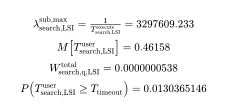

In [98]:
max_load_executor_search_LSI = 1 / time_execute_search_LSI
prob_timeout_search_LSI = user.prob_timeout(
    MATH_MODEL_INPUT.timeout,
    user_time_k,
    user_time_theta,
    cluster_time_k,
    cluster_time_theta,
    queue_time_execute_search_LSI,
    deterministic_part_of_tcsi_search_LSI,
    query_size,
    pk_per_fk_cardinality_per_replicaset,
    MATH_MODEL_INPUT.replicaset_count,
    MATH_MODEL_INPUT.row_size,
    MATH_MODEL_INPUT.user_net_speed,
)

output(rf"""
$#max_subintensity_search_LSI = 1 / #time_execute_search_LSI = {max_load_executor_search_LSI:.3f}$

$M[#time_user_search_LSI] = {time_user_search_LSI_mean:.5f}$

$#queue_time_total_search_LSI = {2 * queue_time_execute_search_LSI:.10f}$

$P(#time_user_search_LSI >= #timeout) = {prob_timeout_search_LSI:.10f}$
""")